# Graph Classification with Graph Neural Networks

**Graph Neural Networks (GNNs)** aim to generalize classical deep learning concepts to irregular structured data (in contrast to images or texts) and to enable neural networks to reason about objects and their relations.

This tutorial is based on the **[PyTorch Geometric (PyG) library](https://github.com/rusty1s/pytorch_geometric)**. PyG is a powerful and flexible Python library built on top of [PyTorch](https://pytorch.org/), designed specifically for working with graph-structured data. It simplifies the process of building and training Graph Neural Networks (GNNs)—a class of models that learn from data represented as graphs, such as social networks, molecules, or knowledge graphs.


Content in this notebook is based on [PyTorch Geometric tutorial](https://pytorch-geometric.readthedocs.io/en/latest/get_started/colabs.html)

In this tutorial session we will walk through the process of applying **Graph Neural Networks (GNNs) to the task of graph classification**.
Graph classification refers to the problem of classifiying entire graphs, given a **dataset of graphs**, based on some structural graph properties.
Here, we want to embed entire graphs, and we want to embed those graphs in such a way so that they are linearly separable given a task at hand.

![graph classification](img/graph_classification.png)

In [1]:
# First import required packages
import os
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx
import random
from collections import defaultdict
from torch_geometric.nn import GraphConv
from captum.attr import Saliency, IntegratedGradients, KernelShap
import numpy as np
%matplotlib inline

### Understanding the CosmicAI Cluster Dataset

In this block, we dynamically generate a synthetic astrophysics dataset to train our Graph Neural Network (GNN). The goal is to classify whether a galaxy cluster is **Relaxed** (a single, stable sphere) or **Merging** (two clusters actively colliding).

To make this a realistic machine learning challenge, we must prevent the network from "cheating." We do this by burying our signal inside physical noise:

**1. Spatial Distribution (The Layout)**
* **Relaxed (Target 0):** Galaxies are distributed randomly around a single center point.
* **Merging (Target 1):** We create two separate centers of mass and push them close together, simulating an active collision zone in the middle.

**2. Node Features (Noise vs. Signal)**
Instead of raw X, Y, Z coordinates, we give the model two translation-invariant features:
* **Local Sparsity:** The distance to the 5th nearest neighbor.
* **Energy:** A measure of the galaxy's heat. 
    * **The Noise (Supernovae):** We randomly inject massive energy spikes into 25% of the galaxies across *both* cluster types. If the model just looks for "hot nodes," it will fail.
    * **The Signal (Shock Heating):** In merging clusters, the diffuse gas in the central collision plane slams together, creating a subtle but consistent "wall of heat." 

**3. Graph Construction (Message Passing)**
We connect each galaxy to its 5 nearest neighbors. Because the individual node features are so noisy, the GNN **must** use these edges to pass messages. It has to ask its neighbors: *"Are you hot too?"* to differentiate between an isolated random supernova and a contiguous shock front!

In [2]:
import torch
from torch_geometric.data import InMemoryDataset, Data

class CosmicAIClusterDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['cosmic_ai_clusters.pt']

    def download(self):
        pass

    def process(self):
        data_list = []
        num_graphs = 600 
        
        for _ in range(num_graphs):
            label = torch.randint(0, 2, (1,)).item()
            num_galaxies = torch.randint(50, 150, (1,)).item()
            
            # --- Base Energy & Random Supernovae (Noise for BOTH classes) ---
            # Background energy (cool, stable gas)
            energy = torch.rand(num_galaxies, 1) * 2.0 
            
            # 25% of galaxies in ALL clusters randomly spike in energy (up to 8.0)
            # This acts as 'Supernovae' noise to prevent the model from cheating
            # and looking for just a single hot node.
            supernova_mask = (torch.rand(num_galaxies, 1) > 0.75).float()
            energy += supernova_mask * (torch.rand(num_galaxies, 1) * 8.0)
            
            if label == 0:
                # Relaxed: Single core, wider spread
                # Creates a normal distribution of 3D coordinates (x, y, z) 
                # centered at (0,0,0) with a spread of 1.5
                pos = torch.randn(num_galaxies, 3) * 1.5
                
            else:
                # Merging: Two cores, but pushed closer together to create overlap/ambiguity
                # The first half is shifted to the right (+ 1.2) and 
                # the second half is shifted to the left (- 1.2).
                pos1 = torch.randn(num_galaxies // 2, 3) * 1.2 + torch.tensor([1.2, 0.0, 0.0])
                pos2 = torch.randn(num_galaxies - num_galaxies // 2, 3) * 1.2 - torch.tensor([1.2, 0.0, 0.0])
                pos = torch.cat([pos1, pos2], dim=0)
                
                # --- Shock Heating ---
                # Find galaxies that are caught in the collision plane (near x = 0)
                dist_to_collision = torch.abs(pos[:, 0]).unsqueeze(1)
                shock_zone = (dist_to_collision < 0.4).float()
                
                # Add a moderate, consistent heat to the shock zone.
                # Individually, these look like supernovae. Together, they form a wall of heat.
                energy += shock_zone * (torch.rand(num_galaxies, 1) * 2.5 + 2.0)

            # --- KNN --- 
            # Euclidean distance between every galaxy and 
            # every other galaxy
            dist = torch.cdist(pos, pos)
            dist.fill_diagonal_(float('inf'))
            k = 5
            knn_dists, col = torch.topk(dist, k=k, largest=False)
            row = torch.arange(num_galaxies).view(-1, 1).expand(-1, k)
            edge_index = torch.stack([row.flatten(), col.flatten()], dim=0)
            
            # --- Node Features ---
            # 1. Local Sparsity (Distance to 5th nearest neighbor)
            local_sparsity = knn_dists[:, -1].unsqueeze(1)
            
            # 2. Energy
            x = torch.cat([local_sparsity, energy], dim=1)
            
            y = torch.tensor([label], dtype=torch.long)
            data = Data(x=x, edge_index=edge_index, pos=pos, y=y)
            data_list.append(data)
            
        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])

# Initialize the new, explainable dataset
dataset = CosmicAIClusterDataset(root='./data/CosmicAI')

print(f'Dataset: {dataset}:')
print(f'====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')

Dataset: CosmicAIClusterDataset(600):
Number of graphs: 600
Number of features: 2


Each graph in PyTorch Geometric is represented by a single [`Data`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) object, which holds all the information to describe its graph representation.
We can print the data object anytime via `print(data)` to receive a short summary about its attributes and their shapes:

In [3]:
# Grab the first galaxy cluster graph from the dataset
data = dataset[0]

# Print the summary of its attributes and shapes
print(data)
print('==============================================================')

# Gather some statistics about the graph
print(f'Number of nodes (galaxies): {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree (connections per galaxy): {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[82, 2], edge_index=[2, 410], y=[1], pos=[82, 3])
Number of nodes (galaxies): 82
Number of edges: 410
Average node degree (connections per galaxy): 5.00
Has isolated nodes: False
Has self-loops: False
Is undirected: False


We can see that this `data` object holds 4 attributes:
(1) The `edge_index` property holds the information about the **graph connectivity**, *i.e.*, a tuple of source and destination node indices for each edge.
(2) **node features** as `x` (each galaxy is assigned a 2-dim feature vector for Local Sparsity and Energy).
(3) **node labels** as `y` (0 for Relaxed Cluster, 1 for Merging Cluster).
(4) **node positions** as `pos` (the 3D spatial coordinates of each galaxy).

The `data` object also provides some **utility functions** to infer some basic properties of the underlying graph. For example, we can easily infer whether there are isolated nodes, self-loops, or if the graph is undirected.

Let us now inspect the `edge_index` property in more detail:

In [4]:
edge_index = data.edge_index
print(edge_index.t())

tensor([[ 0, 18],
        [ 0,  6],
        [ 0, 29],
        [ 0, 31],
        [ 0, 14],
        [ 1, 14],
        [ 1, 31],
        [ 1, 18],
        [ 1, 19],
        [ 1, 23],
        [ 2, 25],
        [ 2, 34],
        [ 2, 33],
        [ 2, 26],
        [ 2, 30],
        [ 3, 25],
        [ 3, 67],
        [ 3, 33],
        [ 3, 47],
        [ 3, 48],
        [ 4, 52],
        [ 4, 24],
        [ 4, 75],
        [ 4, 34],
        [ 4, 25],
        [ 5, 15],
        [ 5, 17],
        [ 5, 51],
        [ 5,  7],
        [ 5, 20],
        [ 6,  0],
        [ 6, 36],
        [ 6, 28],
        [ 6, 18],
        [ 6, 11],
        [ 7, 20],
        [ 7, 51],
        [ 7,  5],
        [ 7, 15],
        [ 7, 28],
        [ 8, 50],
        [ 8, 24],
        [ 8, 43],
        [ 8, 52],
        [ 8, 75],
        [ 9, 32],
        [ 9, 78],
        [ 9, 61],
        [ 9, 12],
        [ 9, 37],
        [10, 31],
        [10,  6],
        [10, 11],
        [10, 18],
        [10,  0],
        [1

By printing `edge_index`, we can understand how PyG represents graph connectivity internally.
We can see that for each edge, `edge_index` holds a tuple of two node indices, where the first value describes the node index of the source node and the second value describes the node index of the destination node of an edge.

This representation is known as the **COO format (coordinate format)** commonly used for representing sparse matrices.
Instead of holding the adjacency information in a dense representation $\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$, PyG represents graphs sparsely, which refers to only holding the coordinates/values for which entries in $\mathbf{A}$ are non-zero.

Importantly, PyG does not distinguish between directed and undirected graphs, and treats undirected graphs as a special case of directed graphs in which reverse edges exist for every entry in `edge_index`.

We can further visualize the graph by converting it to the `networkx` library format, which implements, in addition to graph manipulation functionalities, powerful tools for visualization:

PyTorch Geometric provides some useful utilities for working with graph datasets, *e.g.*, we can shuffle the dataset and use the first 480 graphs as training graphs, while using the remaining ones for testing:

In [5]:
dataset = dataset.shuffle()

train_dataset = dataset[:480]
test_dataset = dataset[480:]

print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

Number of training graphs: 480
Number of test graphs: 120


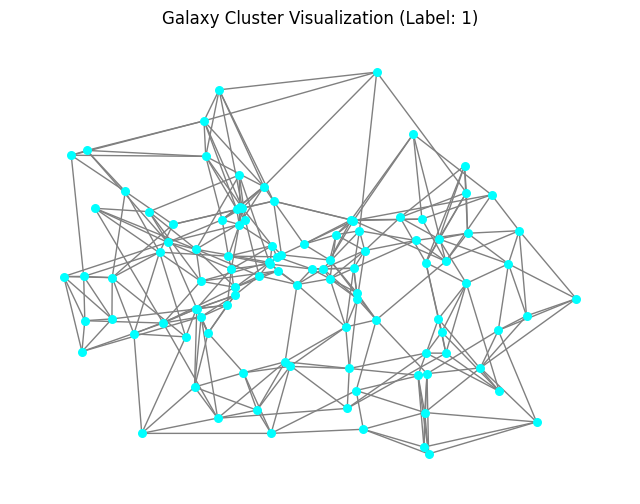

In [6]:
def draw_cluster(data, edge_mask=None):
    # Convert PyG graph to NetworkX for plotting
    g = to_networkx(data, to_undirected=True)
    
    # Extract a 2D projection of the 3D spatial coordinates we generated
    pos = {i: [data.pos[i][0].item(), data.pos[i][1].item()] for i in range(data.num_nodes)}
    
    if edge_mask is None:
        edge_color = 'gray'
        widths = 1.0
    else:
        # Map the explanation masks to edge colors and thickness
        edge_color = [edge_mask.get((u, v), 0) for u, v in g.edges()]
        widths = [x * 8 for x in edge_color]
        
    nx.draw(g, pos=pos, node_size=30, width=widths,
            edge_color=edge_color, edge_cmap=plt.cm.magma,
            node_color='cyan', edge_vmin=0.0, edge_vmax=1.0)
    plt.show()

# Grab a random cluster from the training set to visualize
sample_data = random.choice([t for t in train_dataset])
plt.figure(figsize=(8, 6))
plt.title(f"Galaxy Cluster Visualization (Label: {sample_data.y.item()})")
draw_cluster(sample_data)

## Mini-batching of graphs

Since graphs in graph classification datasets are usually small, a good idea is to **batch the graphs** before inputting them into a Graph Neural Network to guarantee full GPU utilization.
In the image or language domain, this procedure is typically achieved by **rescaling** or **padding** each example into a set of equally-sized shapes, and examples are then grouped in an additional dimension.
The length of this dimension is then equal to the number of examples grouped in a mini-batch and is typically referred to as the `batch_size`.

However, for GNNs the two approaches described above are either not feasible or may result in a lot of unnecessary memory consumption.
Therefore, PyTorch Geometric opts for another approach to achieve parallelization across a number of examples. Here, adjacency matrices are stacked in a diagonal fashion (creating a giant graph that holds multiple isolated subgraphs), and node and target features are simply concatenated in the node dimension:
![mini-batching](img/mini-batching.png)

This procedure has some crucial advantages over other batching procedures:

1. GNN operators that rely on a message passing scheme do not need to be modified since messages are not exchanged between two nodes that belong to different graphs.

2. There is no computational or memory overhead since adjacency matrices are saved in a sparse fashion holding only non-zero entries, *i.e.*, the edges.

PyTorch Geometric automatically takes care of **batching multiple graphs into a single giant graph** with the help of the [`torch_geometric.data.DataLoader`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.DataLoader) class:

In [7]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

for step, data in enumerate(train_loader):
    print(f'Step {step + 1}:')
    print('=======')
    print(f'Number of graphs in the current batch: {data.num_graphs}')
    print(data)
    print()

Step 1:
Number of graphs in the current batch: 64
DataBatch(x=[6090, 2], edge_index=[2, 30450], y=[64], pos=[6090, 3], batch=[6090], ptr=[65])

Step 2:
Number of graphs in the current batch: 64
DataBatch(x=[6287, 2], edge_index=[2, 31435], y=[64], pos=[6287, 3], batch=[6287], ptr=[65])

Step 3:
Number of graphs in the current batch: 64
DataBatch(x=[6633, 2], edge_index=[2, 33165], y=[64], pos=[6633, 3], batch=[6633], ptr=[65])

Step 4:
Number of graphs in the current batch: 64
DataBatch(x=[6463, 2], edge_index=[2, 32315], y=[64], pos=[6463, 3], batch=[6463], ptr=[65])

Step 5:
Number of graphs in the current batch: 64
DataBatch(x=[6119, 2], edge_index=[2, 30595], y=[64], pos=[6119, 3], batch=[6119], ptr=[65])

Step 6:
Number of graphs in the current batch: 64
DataBatch(x=[6449, 2], edge_index=[2, 32245], y=[64], pos=[6449, 3], batch=[6449], ptr=[65])

Step 7:
Number of graphs in the current batch: 64
DataBatch(x=[6609, 2], edge_index=[2, 33045], y=[64], pos=[6609, 3], batch=[6609], ptr

Here, we opt for a `batch_size` of 64, leading to 8 (randomly shuffled) mini-batches, containing all $7 \cdot 64+32 = 480$ graphs.

Furthermore, each `Batch` object is equipped with a **`batch` vector**, which maps each node to its respective graph in the batch:

$$
\textrm{batch} = [ 0, \ldots, 0, 1, \ldots, 1, 2, \ldots , n-1]
$$

where n is number of graphs in the batch.

The **`ptr` vector** in the `Batch` object helps keep track of where each individual graph starts and ends within the batched data. It marks the start index of each graph in the concatenated node feature matrix (x). The first value is always 0, and the last value is equal to the total number of nodes in the batch.

## Implementing Graph Neural Networks

After learning about PyG's data handling, it's time to implement our first Graph Neural Network!

For this, we will use on of the most simple GNN operators, the **GCN layer** ([Kipf et al. (2017)](https://arxiv.org/abs/1609.02907)), which is defined as

$$
\mathbf{x}_v^{(\ell + 1)} = \mathbf{W}^{(\ell + 1)} \sum_{w \in \mathcal{N}(v) \, \cup \, \{ v \}} \frac{1}{c_{w,v}} \cdot \mathbf{x}_w^{(\ell)}
$$

where $\mathbf{W}^{(\ell + 1)}$ denotes a trainable weight matrix of shape `[num_output_features, num_input_features]` and $c_{w,v}$ refers to a fixed normalization coefficient for each edge.

PyG implements this layer via [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv), which can be executed by passing in the node feature representation `x` and the COO graph connectivity representation `edge_index`.

Training a GNN for graph classification usually follows a simple recipe:

1. Embed each node by performing multiple rounds of message passing
2. Aggregate node embeddings into a unified graph embedding (**readout layer**)
3. Train a final classifier on the graph embedding

There exists multiple **readout layers** in literature, but the most common one is to simply take the average of node embeddings:

$$
\mathbf{x}_{\mathcal{G}} = \frac{1}{|\mathcal{V}|} \sum_{v \in \mathcal{V}} \mathcal{x}^{(L)}_v
$$

PyTorch Geometric provides this functionality via [`torch_geometric.nn.global_mean_pool`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.glob.global_mean_pool), which takes in the node embeddings of all nodes in the mini-batch and the assignment vector `batch` to compute a graph embedding of size `[batch_size, hidden_channels]` for each graph in the batch.

The final architecture for applying GNNs to the task of graph classification then looks as follows and allows for complete end-to-end training:

In [8]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch, edge_weight=None):
        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index, edge_weight)
        x = x.relu()
        x = self.conv2(x, edge_index, edge_weight)
        x = x.relu()
        x = self.conv3(x, edge_index, edge_weight)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x
model = GCN(hidden_channels=64)
print(model)

GCN(
  (conv1): GCNConv(2, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


Here, we first initialize all of our building blocks in `__init__` and define the computation flow of our network in `forward`.
We first define and stack **three graph convolution layers**, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 "hops" away).

Training our model is very similar to any other PyTorch model.
In addition to defining our network architecture, we define a loss critertion (here, [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)) and initialize a stochastic gradient optimizer (here, [`Adam`](https://pytorch.org/docs/stable/optim.html?highlight=adam#torch.optim.Adam)).
After that, we perform multiple rounds of optimization, where each round consists of a forward and backward pass to compute the gradients of our model parameters w.r.t. to the loss derived from the forward pass.
If you are not new to PyTorch, this scheme should appear familar to you. 
Otherwise, the PyTorch docs provide [a good introduction on how to train a neural network in PyTorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer).


Let's train our network for a few epochs to see how well it performs on the training as well as test set:

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()

    for data in train_loader:  # Iterate in batches over the training dataset.
         data = data.to(device)
         out = model(data.x, data.edge_index, data.batch)  # Perform a single forward pass.
         loss = criterion(out, data.y)  # Compute the loss.
         loss.backward()  # Derive gradients.
         optimizer.step()  # Update parameters based on gradients.
         optimizer.zero_grad()  # Clear gradients.

def test(loader):
     model.eval()

     correct = 0
     for data in loader:  # Iterate in batches over the training/test dataset.
         data = data.to(device) 
         out = model(data.x, data.edge_index, data.batch)  
         pred = out.argmax(dim=1)  # Use the class with highest probability.
         correct += int((pred == data.y).sum())  # Check against ground-truth labels.
     return correct / len(loader.dataset)  # Derive ratio of correct predictions.


for epoch in range(1, 171):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Train Acc: 0.6979, Test Acc: 0.6417
Epoch: 002, Train Acc: 0.8104, Test Acc: 0.8417
Epoch: 003, Train Acc: 0.8000, Test Acc: 0.8417
Epoch: 004, Train Acc: 0.7979, Test Acc: 0.7833
Epoch: 005, Train Acc: 0.8021, Test Acc: 0.8083
Epoch: 006, Train Acc: 0.8187, Test Acc: 0.8250
Epoch: 007, Train Acc: 0.8146, Test Acc: 0.8333
Epoch: 008, Train Acc: 0.8063, Test Acc: 0.8333
Epoch: 009, Train Acc: 0.8167, Test Acc: 0.8250
Epoch: 010, Train Acc: 0.8104, Test Acc: 0.8250
Epoch: 011, Train Acc: 0.8187, Test Acc: 0.8583
Epoch: 012, Train Acc: 0.8042, Test Acc: 0.7917
Epoch: 013, Train Acc: 0.7896, Test Acc: 0.7667
Epoch: 014, Train Acc: 0.8187, Test Acc: 0.8333
Epoch: 015, Train Acc: 0.8187, Test Acc: 0.8333
Epoch: 016, Train Acc: 0.8104, Test Acc: 0.8333
Epoch: 017, Train Acc: 0.8187, Test Acc: 0.8333
Epoch: 018, Train Acc: 0.8208, Test Acc: 0.8333
Epoch: 019, Train Acc: 0.8187, Test Acc: 0.8333
Epoch: 020, Train Acc: 0.8229, Test Acc: 0.8667
Epoch: 021, Train Acc: 0.8250, Test Acc:

As one can see, our model reaches around **85% test accuracy**.
Reasons for the fluctations in accuracy can be explained by the rather small dataset, and usually disappear once one applies GNNs to larger datasets.


### Explaining the GNN: Visualizing the Shock Front

Now that our model has achieved high accuracy, we want to know *why* it made its decisions. Is it actually learning the physics of the collision, or is it just memorizing noise? 

To answer this, we use **Captum**, a model interpretability library. We will use it to interrogate a "Merging" cluster prediction.

**How it works:**
1. **Perturbation:** Algorithms like `KernelShap` or `Integrated Gradients` systematically mask (turn off) the mathematical edges connecting the galaxies.
2. **Measurement:** They watch the GNN's output confidence. If turning off an edge doesn't change the prediction, that edge is deemed unimportant. If turning off an edge causes the model's confidence to plummet, that edge is marked as highly important.
3. **Beating the Noise:** Because random supernovae are surrounded by cold galaxies, the message passing there is weak, so Captum gives those edges an **Importance Score near 0**. However, the edges connecting the tightly packed, warm galaxies in the collision zone are critical for the classification, earning an **Importance Score near 1.0**.

When we plot the results below, the thickness and brightness of the lines represent the Importance Score. You should see the chaotic background noise fade away, revealing a bright, thick spine of edges directly down the middle of the cluster—proving the GNN successfully learned to identify the physical shock zone!

In [10]:
def model_forward(edge_mask, data):
    # GNNs usually expect batches of graphs. 
    # Creates a dummy batch tensor 
    batch = torch.zeros(data.x.shape[0], dtype=int).to(device)
    # Use edge_mask instead of edge_index. Explainer will use the argument
    out = model(data.x, data.edge_index, batch, edge_mask.view(-1))
    return out


def explain(method, data, target=1):
    # Starts by turning all edges fully on
    input_mask = torch.ones(data.edge_index.shape[1]).requires_grad_(True).to(device)
    if method == 'ig':
        ig = IntegratedGradients(model_forward)
        mask = ig.attribute(input_mask, target=target,
                            additional_forward_args=(data,),
                            internal_batch_size=data.edge_index.shape[1])
    elif method == 'saliency':
        saliency = Saliency(model_forward)
        mask = saliency.attribute(input_mask, target=target,
                                  additional_forward_args=(data,))
    elif method == 'shap':
        input_mask = torch.unsqueeze(input_mask, 0)
        shap = KernelShap(model_forward)
        mask = shap.attribute(input_mask, target=target,
                              additional_forward_args=(data,),
                              n_samples=2000)
        mask = mask[0]
    else:
        raise Exception('Unknown explanation method')
        
    # Some gradients might be negative
    edge_mask = np.abs(mask.cpu().detach().numpy())
    if edge_mask.max() > 0:  # avoid division by zero
        edge_mask = edge_mask / edge_mask.max()
    return edge_mask

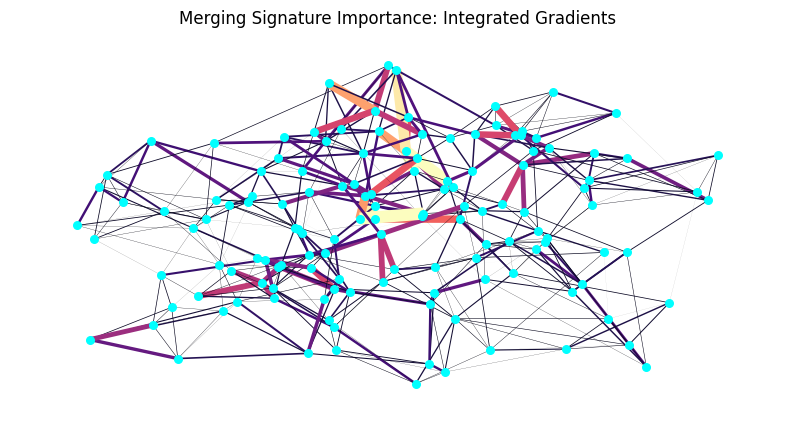

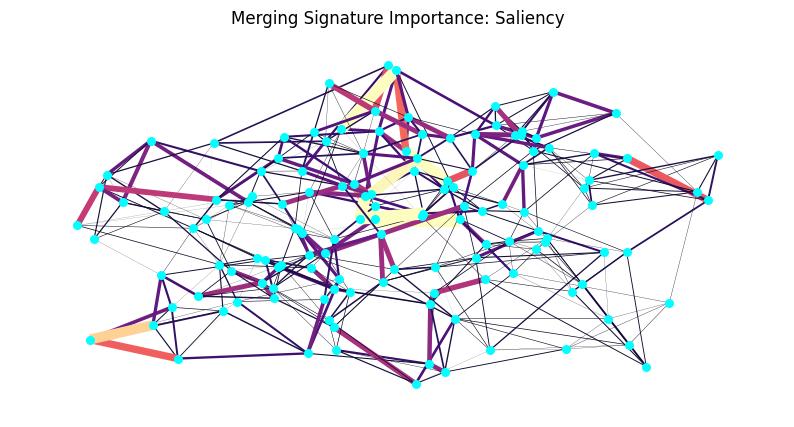

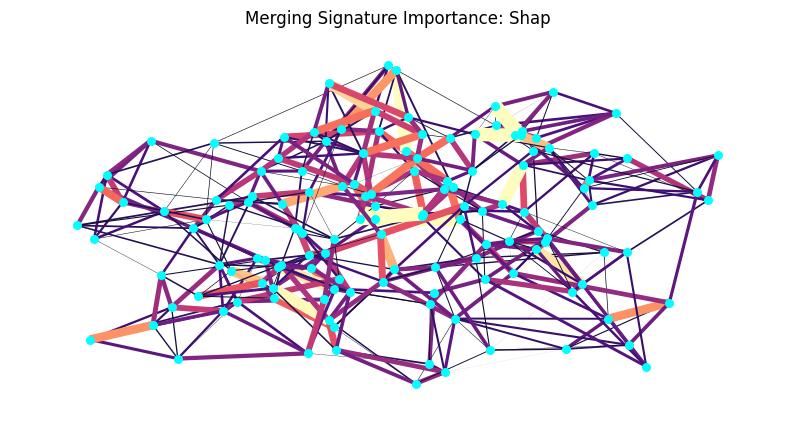

In [11]:
def aggregate_edge_directions(edge_mask, data):
    edge_mask_dict = defaultdict(float)
    # Adds the scores together so that the connection between Galaxy A and Galaxy B has one score.
    for val, u, v in list(zip(edge_mask, *data.edge_index)):
        u, v = u.item(), v.item()
        if u > v:
            u, v = v, u
        edge_mask_dict[(u, v)] += val
    return edge_mask_dict
    
# Let's specifically look at a "Merging Cluster" (Target = 1) to see what the model learned
data = random.choice([t for t in test_dataset if t.y.item() == 1])

for title, method in [('Integrated Gradients', 'ig'), ('Saliency', 'saliency'), ('Shap', 'shap')]:
    edge_mask = explain(method, data.to(device), target=1)
    edge_mask_dict = aggregate_edge_directions(edge_mask, data)
    
    plt.figure(figsize=(10, 5))
    plt.title(f"Merging Signature Importance: {title}")
    draw_cluster(data, edge_mask_dict)

### The Math Behind the Explainer

Now we look at three popular attribution methods. First, we calculate the gradient of the output with respect to the edge weights $w_{e_i}$. Edge weights are initially one for all edges. 

**1. Saliency**
For the saliency method, we use the absolute value of the gradient as the attribution value for each edge:
$$S_{e_i} = \left| \frac{\partial F(x)}{\partial w_{e_i}} \right|$$
Where $x$ is the input and $F(x)$ is the output of the GNN model on input $x$.

**2. Integrated Gradients**
For the Integrated Gradients method, we interpolate between the current input and a baseline input where the weight of all edges is zero, and accumulate the gradient values for each edge:
$$IG_{e_i} = \int_{\alpha=0}^{1} \frac{\partial F(x_\alpha)}{\partial w_{e_i}} d\alpha$$
Where $x_\alpha$ is the same as the original input graph but the weight of all edges is set to $\alpha$. The complete formulation is more complicated, but since our initial edge weights are equal to one and the baseline is zero, it can be simplified to the formulation above. Of course, this cannot be calculated directly and is approximated by a discrete sum.

**3. KernelSHAP**
Shapley value is an attribution method based on a concept from cooperative game theory. This method involves taking each permutation of the input features and adding them one-by-one to a given baseline. The output difference after adding each feature corresponds to its contribution, and these differences are averaged over all permutations to obtain the attribution. This method is extremely computationally intensive. For the KernelSHAP method, we obtain Shapley Values using the LIME framework, which is more efficient than directly computing Shapley Values.

*Implementation Note: We use the `captum` library for calculating these attribution values. We defined the `model_forward` function earlier to format the inputs and handle the batched edge weights so Captum can evaluate the graph.*

## Conclusion

In this tutorial, you have learned how to apply GNNs to the task of graph classification.
You have learned how graphs can be batched together for better GPU utilization, and how to apply readout layers for obtaining graph embeddings. You have also learned how to explain GNN predictions.
